In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as scipy_linalg

plt.rcdefaults()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']


# Generate the original MSO5 series using the same method described in the paper
def generate_mso5(n_total=1000):
    phi = np.array([0.2, 0.311, 0.42, 0.51, 0.63], dtype=np.float64)
    t = np.arange(1, n_total + 1, dtype=np.float64)
    series = np.sum(np.sin(t[:, None] * phi[None, :]), axis=1)
    return t, series, phi


# The generated time series u(t) and −u(t) were linearly mapped to an appropriate voltage range (−1 V, −0.5 V), as mentioned in the paper
def linear_map(series, output_min=-1.0, output_max=-0.5):
    series_min, series_max = np.min(series), np.max(series)
    return output_min + (series - series_min) / (series_max - series_min) * (output_max - output_min)

# Add noise to the signal injected in the static tanh
def add_awgn(signal, snr_db, noise_seed=0):
    signal = np.asarray(signal, dtype=np.float64)
    if snr_db is None or np.isinf(snr_db):
        return signal.copy(), np.zeros_like(signal), 0.0

    rng = np.random.default_rng(noise_seed)
    signal_power = np.mean(signal ** 2)
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise_std = np.sqrt(noise_power)
    noise = rng.normal(0.0, noise_std, size=signal.shape)
    return signal + noise, noise, noise_std


def prepare_static_tanh_states(series, n_back_gate=21, snr_db=np.inf, noise_seed=0):
    input_u = linear_map(series, -1.0, -0.5)
    input_minus_u = linear_map(-series, -1.0, -0.5)

    input_u = np.repeat(input_u[:, None], n_back_gate, axis=1)
    input_minus_u = np.repeat(input_minus_u[:, None], n_back_gate, axis=1)
    tanh_input_clean = np.concatenate([input_u, input_minus_u], axis=1)

    tanh_input_noisy, noise, noise_std = add_awgn(tanh_input_clean, snr_db, noise_seed)
    states = np.tanh(tanh_input_noisy)

    return states, tanh_input_clean, tanh_input_noisy, noise, noise_std


def build_one_step_dataset(states, target_series, memory_steps=4):
    feature_list, target_list, target_time_steps = [], [], []

    for target_index in range(100, 1000):
        present_index = target_index - 1
        state_history = [states[present_index - delay] for delay in range(memory_steps)]
        feature_list.append(np.concatenate(state_history))
        target_list.append(target_series[target_index])
        target_time_steps.append(target_index + 1)

    return np.asarray(feature_list), np.asarray(target_list), np.asarray(target_time_steps)


def standardise_columns(x_train, x_test):
    # Training-set statistics only
    mean = x_train.mean(axis=0, keepdims=True)
    std = x_train.std(axis=0, keepdims=True)
    std = np.where(std > 1e-12, std, 1.0)

    return (x_train - mean) / std, (x_test - mean) / std


def fit_ridge(x_train, y_train, ridge_alpha=1e-4):
    xa = np.column_stack([x_train, np.ones(len(x_train))])
    gram, rhs = xa.T @ xa, xa.T @ y_train
    penalty = ridge_alpha * np.eye(gram.shape[0])
    penalty[-1, -1] = 0.0
    return scipy_linalg.solve(gram + penalty, rhs, assume_a='pos', check_finite=False)


def predict_ridge(x, weights):
    return np.column_stack([x, np.ones(len(x))]) @ weights


def compute_nrmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2) / np.var(y_true))


In [2]:
def run_one_noise_seed(series, n_back_gate, memory_steps, ridge_alpha, snr_db, noise_seed):
    states, clean_input, noisy_input, noise, noise_std = prepare_static_tanh_states(series, n_back_gate, snr_db, noise_seed)

    features, target, target_time_steps = build_one_step_dataset(states, series, memory_steps)

    # Target steps 101–700: 600 training samples
    # Target steps 701–1000: 300 testing samples
    x_train, y_train = features[:600], target[:600]
    x_test, y_test = features[600:], target[600:]
    x_train, x_test = standardise_columns(x_train, x_test)

    weights = fit_ridge(x_train, y_train, ridge_alpha)
    test_prediction = predict_ridge(x_test, weights)

    test_nrmse = compute_nrmse(y_test, test_prediction)

    return test_nrmse, y_train, y_test, test_prediction, clean_input, noisy_input


def run_static_tanh_experiment(N_TOTAL, N_BACK_GATE, MEMORY_STEPS, RIDGE_ALPHA, SNR_DB, NOISE_SEED_LIST):
    t, series, phi = generate_mso5(N_TOTAL)
    test_seed_results = []

    for noise_seed in NOISE_SEED_LIST:
        test_nrmse, y_train, y_test, test_prediction, clean_input, noisy_input = run_one_noise_seed(series, N_BACK_GATE, MEMORY_STEPS, RIDGE_ALPHA, SNR_DB, noise_seed)

        test_seed_results.append(test_nrmse)

    ddof = 1 if len(NOISE_SEED_LIST) > 1 else 0
    test_mean, test_std = np.mean(test_seed_results), np.std(test_seed_results, ddof=ddof)

    return test_mean, test_std

### Set parameters and run the experiments


In [3]:
# Published source data from the paper
paper_nrmse = 0.105

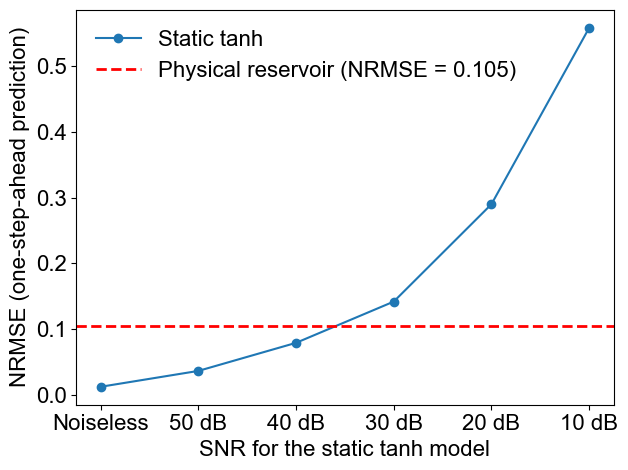

In [4]:
N_TOTAL = 1000
N_BACK_GATE = 21
MEMORY_STEPS = 4
NOISE_SEED_LIST = [0, 1, 2, 3, 4]

SNR_DB_LIST = [np.inf, 50, 40, 30, 20, 10]
RIDGE_ALPHA_LIST = [1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8]

test_nrmse_mean_list = []
test_nrmse_std_list = []

for i in range(len(SNR_DB_LIST)):
    SNR_DB = SNR_DB_LIST[i]
    RIDGE_ALPHA = RIDGE_ALPHA_LIST[i]

    test_mean, test_std = run_static_tanh_experiment(
    N_TOTAL, N_BACK_GATE, MEMORY_STEPS, RIDGE_ALPHA, SNR_DB, NOISE_SEED_LIST
)
    
    test_nrmse_mean_list.append(test_mean)
    test_nrmse_std_list.append(test_std)

plt.figure()
plt.plot(np.arange(len(SNR_DB_LIST)), test_nrmse_mean_list, label='Static tanh', marker='o')


plt.xticks(
    np.arange(len(SNR_DB_LIST)),
    ["Noiseless" if np.isinf(snr) else f"{snr:g} dB" for snr in SNR_DB_LIST]
)


plt.axhline(
    y=paper_nrmse,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Physical reservoir (NRMSE = 0.105)'
)

font = 16
plt.xlabel("SNR for the static tanh model", fontsize=font)
plt.ylabel("NRMSE (one-step-ahead prediction)", fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.legend(frameon=0, fontsize=font, loc='upper left')
plt.tight_layout()
plt.show()
# plt.savefig('optoelectronic_synapse.png', dpi=800, transparent=1)